In [ ]:

import kagglehub
kmader_skin_cancer_mnist_ham10000_path = kagglehub.dataset_download('kmader/skin-cancer-mnist-ham10000')

print('Data source import complete.')


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.optim as optim

In [ ]:
from torchvision import transforms
from PIL import Image
import os

# Define paths
data_dir_part1 = "/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1"
data_dir_part2 = "/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2"
metadata_path = "/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv"

In [ ]:
meta_data = pd.read_csv(metadata_path)
# print(len(meta_data))
meta_data = meta_data.drop_duplicates(subset=["lesion_id"],keep = 'first' )
# print(len(meta_data))
meta_data.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear
6,HAM_0002761,ISIC_0029176,bkl,histo,60.0,male,face
8,HAM_0005132,ISIC_0025837,bkl,histo,70.0,female,back


In [ ]:
meta_data['dx'].unique()

array(['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec'], dtype=object)

In [ ]:
malignant_dx = ['mel','bcc','akiec'] # akiec is premalignant

labels = [1 if x in malignant_dx else 0 for x in meta_data['dx']]
meta_data['label'] = labels

In [ ]:
from torch.utils.data import Dataset

class CancerDataset(Dataset):
    def __init__(self, metadata, dir1, dir2, transform=None):
        self.dir1 = dir1
        self.dir2 = dir2
        self.metadata = metadata.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        img_name = os.path.join(self.dir1, self.metadata.iloc[idx]['image_id'] + '.jpg')
        if not os.path.exists(img_name):
            img_name = os.path.join(self.dir2, self.metadata.iloc[idx]['image_id'] + '.jpg')

        image = Image.open(img_name)
        label = self.metadata.iloc[idx]['label']

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(meta_data, test_size=0.3, stratify=meta_data['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'])

In [ ]:
train_dataset = CancerDataset(train_df, data_dir_part1,data_dir_part2 , train_transform)
val_dataset = CancerDataset(val_df, data_dir_part1,data_dir_part2, val_transform)
test_dataset = CancerDataset(test_df,  data_dir_part1,data_dir_part2, val_transform)

In [ ]:
batch_size = 32
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size)

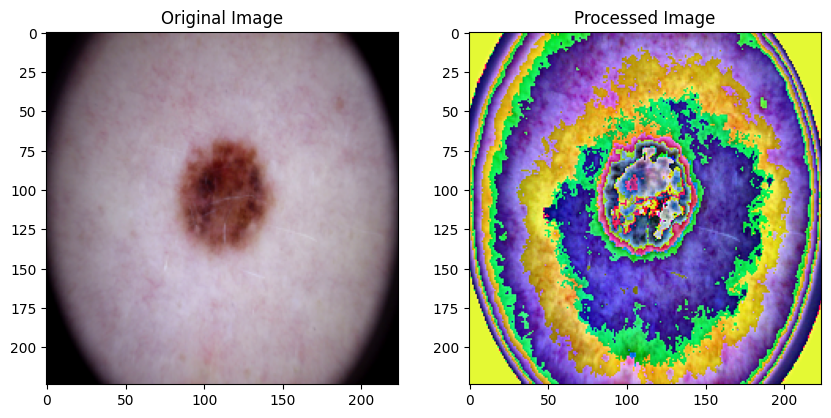

In [ ]:
import matplotlib.pyplot as plt

tensor_image = train_dataset[50][0]

mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])
unnormalized_tensor = tensor_image * std[:, None, None] + mean[:, None, None]

unnormalized_tensor = torch.clamp(unnormalized_tensor, 0, 1)

to_pil = transforms.ToPILImage()
image1 = to_pil(unnormalized_tensor)
image2 = to_pil(tensor_image)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))


axes[0].imshow(image1)
axes[0].set_title("Original Image")

axes[1].imshow(image2)
axes[1].set_title("Processed Image")

plt.show()

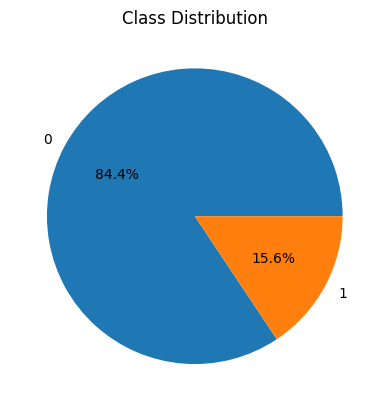

In [ ]:
class_counts = train_df['label'].value_counts()
class_counts.plot(kind='pie',autopct='%1.1f%%')
plt.title('Class Distribution')
plt.ylabel('')
plt.show()

In [ ]:
weights = 1. / class_counts
weights = weights / weights.sum()

In [ ]:
weights

label
0    0.156435
1    0.843565
Name: count, dtype: float64

In [ ]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
from torchvision import models
import torch.nn as nn


model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s]


In [ ]:
criterion = torch.nn.CrossEntropyLoss(
    weight=torch.tensor([weights[0], weights[1]], dtype=torch.float32).to(device)
)

optimizer = optim.Adam(model.parameters(), lr=0.001)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [ ]:
num_epochs = 10
best_acc=0.0
model = model.to(device)

In [ ]:
def evaluate_model(model, dataloader, criterion):
    model.eval()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        with torch.set_grad_enabled(False):
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    loss = running_loss / len(dataloader.dataset)
    acc = running_corrects.double() / len(dataloader.dataset)

    return loss, acc

In [ ]:
for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    print('-' * 10)
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.set_grad_enabled(True):
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    scheduler.step()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = running_corrects.double() / len(train_loader.dataset)

    print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

    # Validation phase
    val_loss, val_acc = evaluate_model(model, val_loader, criterion)
    print(f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}\n')

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'model.pth')

Epoch 1/10
----------
Train Loss: 0.4182 Acc: 0.7533
Val Loss: 0.3769 Acc: 0.7500

Epoch 2/10
----------
Train Loss: 0.4233 Acc: 0.7638
Val Loss: 0.4211 Acc: 0.6527

Epoch 3/10
----------
Train Loss: 0.3977 Acc: 0.7567
Val Loss: 0.4023 Acc: 0.7348

Epoch 4/10
----------
Train Loss: 0.3891 Acc: 0.7684
Val Loss: 0.4489 Acc: 0.8045

Epoch 5/10
----------
Train Loss: 0.3755 Acc: 0.7961
Val Loss: 0.3538 Acc: 0.8170

Epoch 6/10
----------
Train Loss: 0.3614 Acc: 0.7959
Val Loss: 0.3448 Acc: 0.8107

Epoch 7/10
----------
Train Loss: 0.3459 Acc: 0.8111


In [ ]:
loss, acc = evaluate_model(model, test_loader, criterion)

In [ ]:
print (f'loss  = {loss : .2f} , accuracy = {acc.item()*100: .2f} %' )

loss  =  0.69 , accuracy =  42.55 %


In [ ]:
from sklearn.metrics import classification_report

def get_predictions(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    for inputs, labels in dataloader:
        inputs = inputs.to(device)

        with torch.set_grad_enabled(False):
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

# Get predictions
test_labels, test_preds = get_predictions(model, test_loader)

# Classification report
print(classification_report(test_labels, test_preds, target_names=['benign', 'malignant']))

In [ ]:
from skimage.segmentation import mark_boundaries , slic

def segment_image(image, n_segments=50):

    # mean = torch.tensor([0.485, 0.456, 0.406])
    # std = torch.tensor([0.229, 0.224, 0.225])
    # unnormalized_tensor = image * std[:, None, None] + mean[:, None, None]

    # unnormalized_tensor = torch.clamp(unnormalized_tensor, 0, 1)

    if isinstance(image, torch.Tensor):
        image = image.permute(1, 2, 0).cpu().numpy()


    segments = slic(image, n_segments=n_segments,
                   compactness=10, sigma=1, start_label=1)

    plt.imshow(mark_boundaries(image, segments))
    return segments

In [ ]:
# from skimage.segmentation import mark_boundaries
image = test_dataset[1][0]
segments = segment_image(image, n_segments=50)

# LIME

In [ ]:
def generate_perturbations(image, segments, n_samples=1000):
    h, w = segments.shape
    perturbations = []
    masks = []

    for _ in range(n_samples):
        # Random binary mask (0=hidden, 1=visible)

        mask = np.ones((h, w))
        hide_pixels = np.random.choice(np.unique(segments),
                                     size=np.random.randint(1, len(np.unique(segments))),
                                     replace=False)

        for s in hide_pixels:
            mask[segments == s] = 0


        perturbed = image * mask[...]
        perturbations.append(perturbed)
        masks.append(mask.flatten())

    return np.array(perturbations), np.array(masks)

In [ ]:
perturbations , masks = generate_perturbations(image, segments, n_samples=1000)

In [ ]:
perturbation1 = torch.from_numpy(perturbations[0])
mask1 = torch.from_numpy(masks[0])
mask1 = mask1.view(segments.shape[0],segments.shape[1])

In [ ]:
perturbation1.shape

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(15, 5))

ax[0].imshow(image.permute(1, 2, 0))
ax[1].imshow(perturbation1.permute(1, 2, 0))

ax[0].set_title("Original Image")
ax[1].set_title("Perturbed Image")

plt.show()

In [ ]:
import matplotlib.patches as mpatches
plt.figure(figsize=(5,5))
plt.title("Mask")
plt.imshow(mask1)

handles = [
    mpatches.Patch(color='yellow', label='Preserved Segments'),
    mpatches.Patch(color='purple', label='Hidden Segments')
]

plt.legend(handles=handles, loc='lower right', ncol=2, fontsize='x-small')
plt.show()

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def compute_weights(original_mask, perturbed_masks, kernel_width=0.25):
    original_expanded = np.expand_dims(original_mask, 0)

    distances = cosine_similarity(original_expanded, perturbed_masks)[0]

    return np.sqrt(np.exp(-(distances ** 2) / kernel_width ** 2))

In [ ]:
from sklearn.linear_model import Ridge

def explain_prediction(model, image, segments, n_samples=1000):
    # 1. Prepare original image
    original_mask = np.ones(segments.shape).flatten()

    # 2. Generate perturbations
    perturbations, masks = generate_perturbations(image, segments, n_samples)

    # 3. Get model predictions
    with torch.no_grad():
        inputs = torch.stack([(torch.from_numpy(p)).float() for p in perturbations])
        outputs = model(inputs.to(device))
        scores = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()  # Malignant probabilities

    # 4. Compute weights
    weights = compute_weights(original_mask, masks)

    # 5. Fit weighted linear model
    explainer = Ridge(alpha=1.0)
    explainer.fit(masks, scores, sample_weight=weights)

    return explainer.coef_, segments

In [ ]:
def visualize_explanation(image, segments, importance):
    """Highlight important superpixels"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    # Original image
    ax1.imshow(image.permute(1, 2, 0))
    ax1.set_title("Original Image")

    # Explanation heatmap
    seg_importance = np.zeros_like(segments, dtype=float)
    for i, seg in enumerate(np.unique(segments)):
        seg_importance[segments == seg] = importance[i]

    image = image.permute(1, 2, 0).cpu().numpy()

    marked = mark_boundaries(image, segments)
    print (type(image))
    ax2.imshow(marked)
    ax2.imshow(seg_importance, alpha=1, cmap='Reds')
    ax2.set_title("Explanation Heatmap")

    plt.show()

In [ ]:
for i, (a, b) in enumerate(zip(test_preds, test_labels)):
    if a == b and a == 1:
        print(f"First match at index {i}: {a} == {b}")
        break
else:
    print("No match found")

In [ ]:
# 1. Load sample image
sample_idx = 47
image_sample, label = test_dataset[sample_idx]

print (f'Label : {label}   ,  Pred : {test_preds[sample_idx]} , {test_labels[sample_idx]}')
# 2. Segment image
segments = segment_image(image_sample)

In [ ]:
# 3. Generate explanation
importance, segments = explain_prediction(model, image_sample, segments)

In [ ]:
visualize_explanation(image_sample, segments, importance)